In [14]:

import warnings
warnings.filterwarnings('ignore')

print("="*50)
print("EXTREME FRAUD DETECTION TESTS")
print("="*50)


print("\nTest 1 - Tiny village + massive amount:")
check_transaction(
    amt=8999.99, lat=36.0788, long=-81.1781,
    city_pop=50,
    unix_time=1325376018,
    merch_lat=48.8878,
    merch_long=-118.2105
)


print("Test 2 - Huge amount, remote location:")
check_transaction(
    amt=7500.00, lat=71.0000, long=-156.0000,
    city_pop=100,
    unix_time=1625376018,
    merch_lat=25.7617,
    merch_long=-80.1918
)


print("Test 3 - Maximum suspicious transaction:")
check_transaction(
    amt=9999.00, lat=48.8878, long=-118.2105,
    city_pop=149,
    unix_time=1325376018,
    merch_lat=36.0788,
    merch_long=-81.1781
)


print("Test 4 - Real fraud pattern from dataset:")
fraud_sample = train_df[train_df['is_fraud']==1].iloc[0]
print(f"(Using actual fraud transaction from dataset)")
check_transaction(
    amt=fraud_sample['amt'],
    lat=fraud_sample['lat'],
    long=fraud_sample['long'],
    city_pop=fraud_sample['city_pop'],
    unix_time=fraud_sample['unix_time'],
    merch_lat=fraud_sample['merch_lat'],
    merch_long=fraud_sample['merch_long']
)

EXTREME FRAUD DETECTION TESTS

Test 1 - Tiny village + massive amount:
Amount        : $8999.99
Location      : (36.0788, -81.1781)
Merchant Loc  : (48.8878, -118.2105)
City Population: 50
Legitimate %  : 13.77%
Fraud %       : 86.23%
🚨 RESULT: FRAUDULENT TRANSACTION DETECTED!
--------------------------------------------------
Test 2 - Huge amount, remote location:
Amount        : $7500.0
Location      : (71.0, -156.0)
Merchant Loc  : (25.7617, -80.1918)
City Population: 100
Legitimate %  : 97.88%
Fraud %       : 2.12%
✅ RESULT: LEGITIMATE TRANSACTION
--------------------------------------------------
Test 3 - Maximum suspicious transaction:
Amount        : $9999.0
Location      : (48.8878, -118.2105)
Merchant Loc  : (36.0788, -81.1781)
City Population: 149
Legitimate %  : 62.97%
Fraud %       : 37.03%
✅ RESULT: LEGITIMATE TRANSACTION
--------------------------------------------------
Test 4 - Real fraud pattern from dataset:
(Using actual fraud transaction from dataset)
Amount        

In [13]:
def check_transaction(amt, lat, long, city_pop,
                       unix_time, merch_lat, merch_long):

    transaction = np.array([[amt, lat, long, city_pop,
                              unix_time, merch_lat, merch_long]])


    transaction_scaled = scaler.transform(transaction)


    prediction = xgb_model.predict(transaction_scaled)[0]
    probability = xgb_model.predict_proba(transaction_scaled)[0]

    print(f"Amount        : ${amt}")
    print(f"Location      : ({lat}, {long})")
    print(f"Merchant Loc  : ({merch_lat}, {merch_long})")
    print(f"City Population: {city_pop}")
    print(f"Legitimate %  : {probability[0]*100:.2f}%")
    print(f"Fraud %       : {probability[1]*100:.2f}%")

    if prediction == 1:
        print("🚨 RESULT: FRAUDULENT TRANSACTION DETECTED!")
    else:
        print("✅ RESULT: LEGITIMATE TRANSACTION")
    print("-"*50)


print("="*50)
print("TRANSACTION FRAUD DETECTION SYSTEM")
print("="*50)


print("\nTest 1 - Small grocery purchase:")
check_transaction(
    amt=25.50, lat=40.7128, long=-74.0060,
    city_pop=8336817, unix_time=1325376018,
    merch_lat=40.7200, merch_long=-74.0100
)


print("Test 2 - Large suspicious transaction:")
check_transaction(
    amt=1500.00, lat=36.0788, long=-81.1781,
    city_pop=3495, unix_time=1325376018,
    merch_lat=42.1808, merch_long=-112.2620
)


print("Test 3 - Online shopping:")
check_transaction(
    amt=89.99, lat=34.0522, long=-118.2437,
    city_pop=3990456, unix_time=1325376018,
    merch_lat=34.0500, merch_long=-118.2500
)


print("Test 4 - Very large amount:")
check_transaction(
    amt=9999.99, lat=29.7604, long=-95.3698,
    city_pop=2325502, unix_time=1325376018,
    merch_lat=39.9526, merch_long=-75.1652
)

TRANSACTION FRAUD DETECTION SYSTEM

Test 1 - Small grocery purchase:
Amount        : $25.5
Location      : (40.7128, -74.006)
Merchant Loc  : (40.72, -74.01)
City Population: 8336817
Legitimate %  : 95.83%
Fraud %       : 4.17%
✅ RESULT: LEGITIMATE TRANSACTION
--------------------------------------------------
Test 2 - Large suspicious transaction:
Amount        : $1500.0
Location      : (36.0788, -81.1781)
Merchant Loc  : (42.1808, -112.262)
City Population: 3495
Legitimate %  : 83.80%
Fraud %       : 16.20%
✅ RESULT: LEGITIMATE TRANSACTION
--------------------------------------------------
Test 3 - Online shopping:
Amount        : $89.99
Location      : (34.0522, -118.2437)
Merchant Loc  : (34.05, -118.25)
City Population: 3990456
Legitimate %  : 99.65%
Fraud %       : 0.35%
✅ RESULT: LEGITIMATE TRANSACTION
--------------------------------------------------
Test 4 - Very large amount:
Amount        : $9999.99
Location      : (29.7604, -95.3698)
Merchant Loc  : (39.9526, -75.1652)
Cit

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


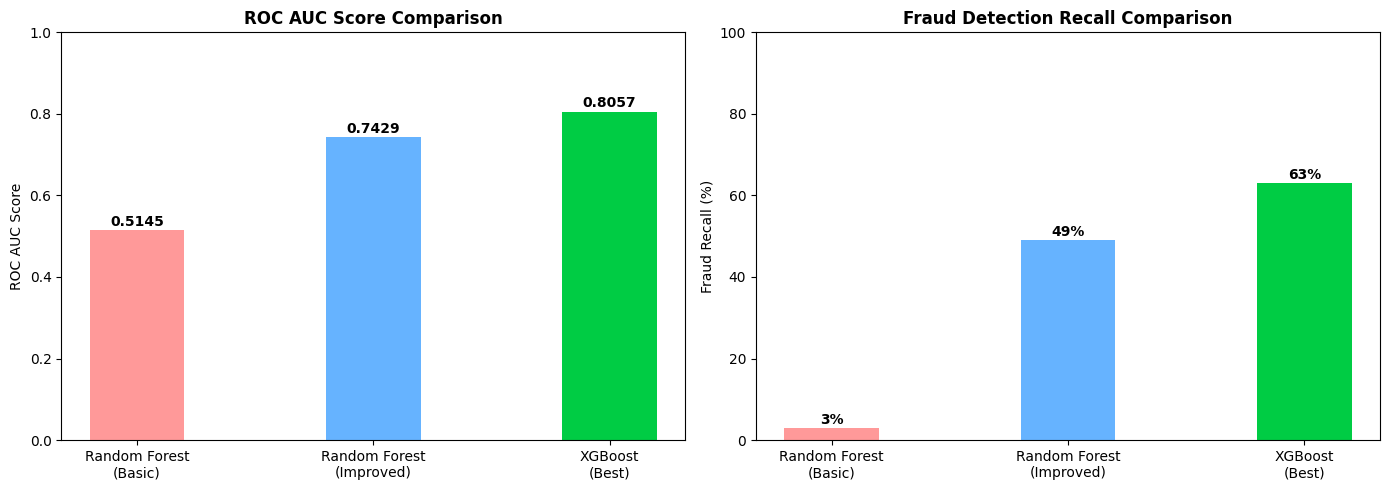


✅ TASK 2 COMPLETE!
Best Model      : XGBoost
Overall Accuracy: 98%
Fraud Recall    : 63%
ROC AUC Score   : 0.8057
Total Records   : 555,719 test transactions


In [12]:
# Final model comparison
model_names = ['Random Forest\n(Basic)',
               'Random Forest\n(Improved)',
               'XGBoost\n(Best)']

roc_scores  = [0.5145, 0.7429, 0.8057]
fraud_recall = [0.03,   0.49,   0.63]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# ROC AUC comparison
bars1 = ax1.bar(model_names, roc_scores,
                color=['#ff9999','#66b3ff','#00cc44'],
                width=0.4)
ax1.set_title('ROC AUC Score Comparison', fontweight='bold')
ax1.set_ylabel('ROC AUC Score')
ax1.set_ylim(0, 1)
for bar, val in zip(bars1, roc_scores):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontweight='bold')

# Fraud Recall comparison
bars2 = ax2.bar(model_names, [r*100 for r in fraud_recall],
                color=['#ff9999','#66b3ff','#00cc44'],
                width=0.4)
ax2.set_title('Fraud Detection Recall Comparison', fontweight='bold')
ax2.set_ylabel('Fraud Recall (%)')
ax2.set_ylim(0, 100)
for bar, val in zip(bars2, fraud_recall):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val*100:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ TASK 2 COMPLETE!")
print("="*45)
print(f"Best Model      : XGBoost")
print(f"Overall Accuracy: 98%")
print(f"Fraud Recall    : 63%")
print(f"ROC AUC Score   : 0.8057")
print(f"Total Records   : 555,719 test transactions")

Training XGBoost...

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    553574
       Fraud       0.11      0.63      0.18      2145

    accuracy                           0.98    555719
   macro avg       0.55      0.81      0.59    555719
weighted avg       1.00      0.98      0.99    555719

ROC AUC Score: 0.8057


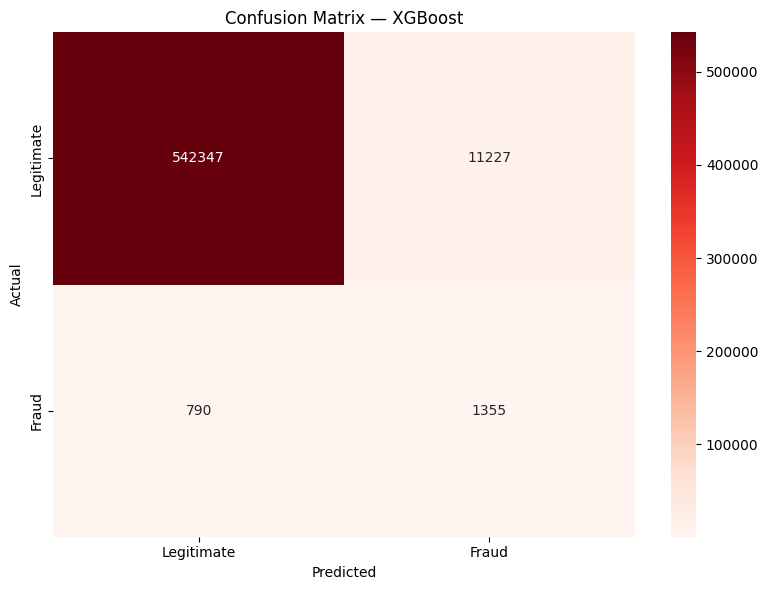

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=['Legitimate','Fraud']))

roc_score = roc_auc_score(y_test, xgb_preds)
print(f"ROC AUC Score: {roc_score:.4f}")


plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Legitimate','Fraud'],
            yticklabels=['Legitimate','Fraud'],
            cmap='Reds')
plt.title('Confusion Matrix — XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Training improved Random Forest...

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.29      0.49      0.36      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.74      0.68    555719
weighted avg       1.00      0.99      0.99    555719

ROC AUC Score: 0.7429


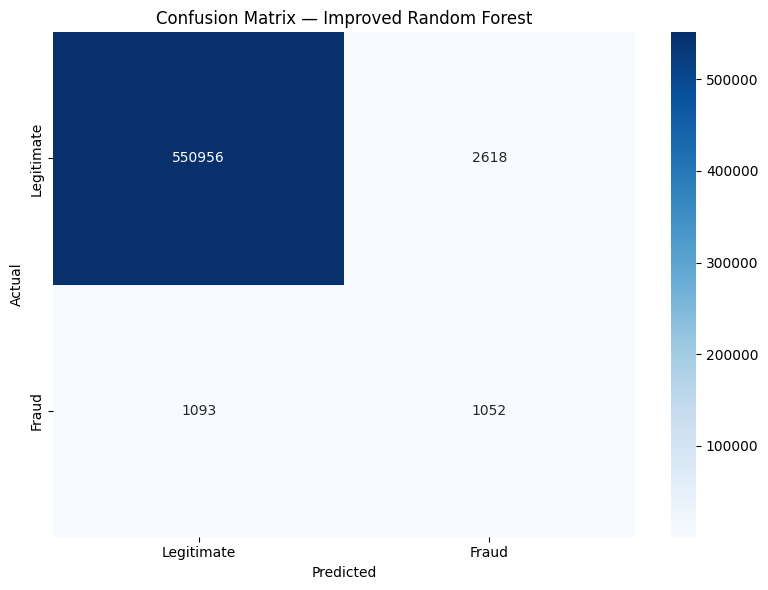

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, roc_auc_score


best_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight={0:1, 1:10},
    random_state=42,
    n_jobs=-1
)

print("Training improved Random Forest...")
best_model.fit(X_train_scaled, y_train)  # use original data
preds = best_model.predict(X_test_scaled)

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, preds,
      target_names=['Legitimate','Fraud']))

# ROC AUC Score
roc_score = roc_auc_score(y_test, preds)
print(f"ROC AUC Score: {roc_score:.4f}")

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Legitimate','Fraud'],
            yticklabels=['Legitimate','Fraud'],
            cmap='Blues')
plt.title('Confusion Matrix — Improved Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00    553574
       Fraud       0.28      0.03      0.05      2145

    accuracy                           1.00    555719
   macro avg       0.64      0.51      0.53    555719
weighted avg       0.99      1.00      0.99    555719

ROC AUC Score: 0.5145


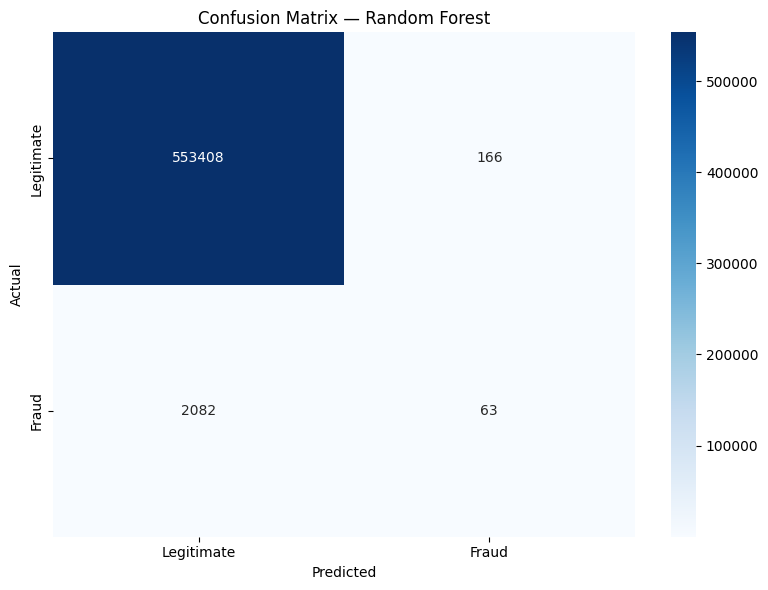

In [9]:

best_model = models["Random Forest"]
preds = best_model.predict(X_test_scaled)


print("Classification Report:")
print(classification_report(y_test, preds,
      target_names=['Legitimate', 'Fraud']))


roc_score = roc_auc_score(y_test, preds)
print(f"ROC AUC Score: {roc_score:.4f}")


plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Legitimate','Fraud'],
            yticklabels=['Legitimate','Fraud'],
            cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree"      : DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100,
                                                   random_state=42,
                                                   n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"✅ {name} Accuracy: {acc:.4f}\n")

best_name = max(results, key=results.get)
print(f"🏆 Best Model: {best_name} — {results[best_name]:.4f}")

Training Logistic Regression...
✅ Logistic Regression Accuracy: 0.9803

Training Decision Tree...
✅ Decision Tree Accuracy: 0.9483

Training Random Forest...
✅ Random Forest Accuracy: 0.9960

🏆 Best Model: Random Forest — 0.9960


In [ ]:

train_df = train_df.dropna(subset=['is_fraud'])
test_df  = test_df.dropna(subset=['is_fraud'])


train_df['is_fraud'] = train_df['is_fraud'].astype(int)
test_df['is_fraud']  = test_df['is_fraud'].astype(int)


features = ['amt', 'lat', 'long', 'city_pop',
            'unix_time', 'merch_lat', 'merch_long']

X_train = train_df[features]
y_train = train_df['is_fraud']
X_test  = test_df[features]
y_test  = test_df['is_fraud']


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Before SMOTE:")
print(f"Legitimate: {sum(y_train==0)}")
print(f"Fraud     : {sum(y_train==1)}")


print("\nApplying SMOTE ")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled, y_train
)

print("\nAfter SMOTE:")
print(f"Legitimate: {sum(y_train_balanced==0)}")
print(f"Fraud     : {sum(y_train_balanced==1)}")
print("\n✅ Data balanced successfully!")

Before SMOTE:
Legitimate: 924702
Fraud     : 5249

Applying SMOTE 

After SMOTE:
Legitimate: 924702
Fraud     : 924702

✅ Data balanced successfully!


In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")
print("\nBefore SMOTE:")
print(f"Legitimate: {sum(y_train==0)}")
print(f"Fraud     : {sum(y_train==1)}")


print("\nApplying SMOTE ")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled, y_train
)

print("\nAfter SMOTE:")
print(f"Legitimate: {sum(y_train_balanced==0)}")
print(f"Fraud     : {sum(y_train_balanced==1)}")
print("\n✅ Data is now perfectly balanced!")

Scaling done!

Before SMOTE:
Legitimate: 924702
Fraud     : 5249

Applying SMOTE 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:399: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


ValueError: Input y contains NaN.

In [ ]:

features = ['amt', 'lat', 'long', 'city_pop',
            'unix_time', 'merch_lat', 'merch_long']

X_train = train_df[features]
y_train = train_df['is_fraud']

X_test  = test_df[features]
y_test  = test_df['is_fraud']

print("Training features shape:", X_train.shape)
print("Test features shape    :", X_test.shape)
print("\nFeatures used:", features)

Training features shape: (929952, 7)
Test features shape    : (555719, 7)

Features used: ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']


Fraud Distribution:
is_fraud
0.0    924702
1.0      5249
Name: count, dtype: int64

Fraud Percentage:
is_fraud
0.0    99.435562
1.0     0.564438
Name: proportion, dtype: float64


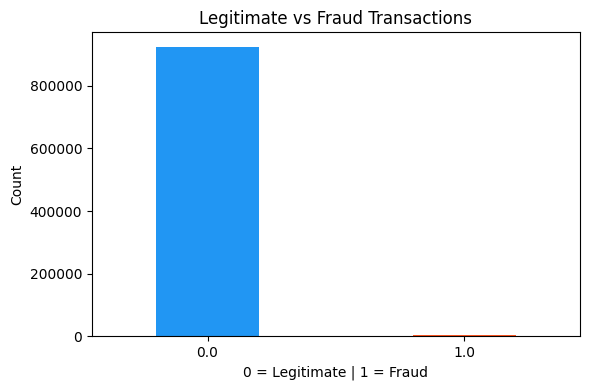

In [ ]:

print("Fraud Distribution:")
print(train_df['is_fraud'].value_counts())
print("\nFraud Percentage:")
print(train_df['is_fraud'].value_counts(normalize=True)*100)


plt.figure(figsize=(6,4))
train_df['is_fraud'].value_counts().plot(
    kind='bar',
    color=['#2196F3','#FF5722'],
    width=0.4
)
plt.title('Legitimate vs Fraud Transactions')
plt.xlabel('0 = Legitimate | 1 = Fraud')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Load training and test data
train_df = pd.read_csv('fraudTrain.csv')
test_df  = pd.read_csv('fraudTest.csv')

# Preview
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nFirst 5 rows:")
print(train_df.head())
print("\nColumns:")
print(train_df.columns.tolist())

Train shape: (929952, 23)
Test shape : (555719, 23)

First 5 rows:
   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -

In [ ]:
# Install libraries
!pip install scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

# Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from imblearn.over_sampling import SMOTE

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [ ]:
import os
print(os.listdir('/content/'))

['.config', 'fraudTest.csv', 'fraudTrain.csv', 'sample_data']
